In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

import numpy as np
import torch
from matplotlib import pyplot as plt

from functools import partial

from pathlib import Path

from cxai import factory, inspector, constants, drsa
from cxai import utils as putils

import pickle
import pandas as pd
from utils import utils_edited as utils

# Introduction

This notebook reproduces Figure 2 in our paper on ["Disentangled Explanations of Neural Network Predictions by Finding Relevant Subspaces"][paper]. It demonstrates how to obtain disentangled explanations from PRCA and DRSA for class *basketball* of the Imagenet dataset. 

We use the Imagenet-pretrained VGG16 from TorchVision and LRP for produce explanations. 

We construct [PRCA][prca] and [DRSA][drsa] from activation and context vectors from Layer Conv4_3. To aid the demonstration, we have pre-extracted these vectors from some 500 training images of class *basketball*. We provide them  at `./data/raw/n02802426`. We also provide the pre-extracted DRSA projection matrices optimized on these vectors.

[prca]: #Principal-Relevance-Subspace-Analysis-(PRCA):-Extracting-a-Maximally-Contributing-Subspace
[drsa]: #Disentangled-Relevant-Subspace-Analysis-(DRSA):-Extracting-Subspaces-for-Disentangled-Explanations

[paper]: http://coming.soon

## Variable Declaration

In [2]:
ARCH = "xresnet1d101-ecg"
LAYER = "block4"
ATTR_METHOD = "gradient"

EXPERIMENT = "exp1.1"
TASK = "superdiagnostic"
SAMPLING_FREQUENCY = 100
LABEL = 3 # for NORM
CLASS_NAMES = ['CD', 'HYP', 'MI', 'NORM', 'STTC'] #["MI", "OTHER", "NORM"]
class_name = CLASS_NAMES[LABEL]  # "NORM"

# Anzahl ECG-Samples (statt Bilder)
TOTAL_ECGS = 3  # Statt TOTAL_IMAGES = 5

NUMBER_SUBSPACES = 4

DATA_DIR = putils.parent_dir(constants.PACKAGE_DIR) / "data"

# ECG-Daten-Pfad (statt ImageNet-Pfad)
ECG_DATA_DIR = "../cxai/data/ecg/"
ECG_LOAD_DIR = f"{ECG_DATA_DIR}/{EXPERIMENT}/{TASK}/layer_{LAYER}/"

## Load Model, Explainer, Standard Scaler

In [3]:
standard_scaler = pickle.load(open(f'../../output/{EXPERIMENT}/data/standard_scaler.pkl', "rb"))

In [4]:
model, (rc_transform, input_transform) = factory.make_model(ARCH, CLASS_NAMES, standard_scaler)

In [5]:
explainer = factory.make_explainer("gradient", model)
print(f"Created explainer: {type(explainer)}")

Created explainer: <class 'cxai.explainers.gradient.GradientExplainer'>


## Load Data

In [6]:
DATA_DIR_ECG = "C:/Users/AliceKitchkin/Repos/ecg_classification/data/ptbxl/"
outputfolder_for_mlb = f'../../output/{EXPERIMENT}/'

# Load PTB-XL data
df, raw_labels = utils.load_dataset(DATA_DIR_ECG, SAMPLING_FREQUENCY)

# Preprocess label data
labels = utils.compute_label_aggregations(raw_labels, DATA_DIR_ECG, TASK)

# Select relevant data and convert to one-hot
X, Y, y, mlb = utils.select_data(df, labels, TASK, min_samples=0, output_folder=outputfolder_for_mlb)

# Nimm nur ein paar Samples der gewünschten Klasse (z.B. NORM = Label 3)
class_indices = np.where(y[:, LABEL] == 1)[0][:TOTAL_ECGS]
ecg_samples = X[class_indices]

Y

Loading PTB-XL data from: C:/Users/AliceKitchkin/Repos/ecg_classification/data/ptbxl/ ptbxl_database.csv


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,scp_codes_len,superdiagnostic,superdiagnostic_len
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,3,[NORM],1
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,2,[NORM],1
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,2,[NORM],1
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,2,[NORM],1
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,2,[NORM],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,ventrikulÄre extrasystole(n) sinustachykardie ...,...,NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr,4,[STTC],1
21834,20703.0,300.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,sinusrhythmus lagetyp normal qrs(t) abnorm ...,...,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,3,[NORM],1
21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,sinusrhythmus lagetyp normal t abnorm in anter...,...,NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr,2,[STTC],1


# Standard Explanation

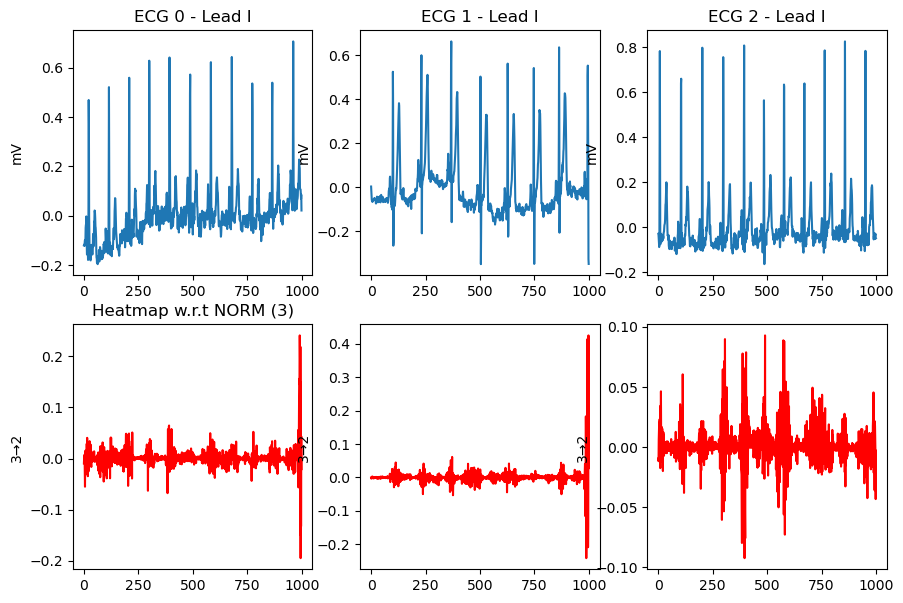

In [ ]:
def visualize_standard_explanations():
    
    ncols = TOTAL_ECGS
    nrows = 2
    
    plt.figure(figsize=(3.5*ncols, 3.5*nrows))
    
    for ix, ecg in enumerate(ecg_samples):
        # ECG-Darstellung (statt Bild)
        plt.subplot(nrows, ncols, ix+1)
        # Zeige erstes Lead als Beispiel
        plt.plot(ecg[:, 0])  # Lead I
        plt.title(f"ECG {ix} - Lead I")
        plt.ylabel("mV")
        
        # Transformiere ECG-Daten korrekt für das Modell
        x = input_transform(ecg)
        
        # Konvertiere zu Tensor falls nötig
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)
        
        # Stelle sicher dass wir 3D haben: (batch, channels, time)
        if x.dim() == 2:  # (1000, 12) -> (1, 1000, 12) -> (1, 12, 1000)
            x = x.unsqueeze(0)  # Batch-Dimension hinzufügen: (1000, 12) -> (1, 1000, 12)
            x = x.transpose(1, 2)  # Dann transponieren: (1, 1000, 12) -> (1, 12, 1000)
        elif x.dim() == 3 and x.shape == (1, 1000, 12):  # Falls schon 3D aber falsche Reihenfolge
            x = x.transpose(1, 2)  # (1, 1000, 12) -> (1, 12, 1000)
        
        # compute standard explanation
        logits, standard_heatmap = explainer.explain(
            x,  # ← Korrekt transformierte ECG-Daten
            LABEL,
        )

        pred_label = np.argmax(logits)
        
        # sum over channels für 1D-Heatmap
        if len(standard_heatmap.shape) > 1:
            standard_heatmap = standard_heatmap.sum(axis=0)

        plt.subplot(nrows, ncols, ncols + ix+1)

        # Einfache Heatmap-Darstellung für 1D-Signal
        plt.plot(standard_heatmap, color='red')
        plt.title(f"Heatmap w.r.t {class_name} ({LABEL})" if ix == 0 else "")
        plt.ylabel(f"{LABEL}→{pred_label}")
        
visualize_standard_explanations()

# Principal Relevance Subspace Analysis (PRCA): Extracting a Maximally Contributing Subspace

Suppose $\mathcal D = \{(\boldsymbol a \in \mathbb{R}^d,\boldsymbol c \in \mathbb{R}^d)\}$ is a collection of activation and context<sup>1</sup> vectors extracted from 500 training images of class *basketball*. Recall the objective of PRCA 

$$
\max_U (U^\top \boldsymbol a)^\top (U^\top \boldsymbol c),
$$

where $U \in \mathbb{R}^{d \times d'}$ is a projection matrix with $U^\top U = I_{d'}$, and $d'$ is the number of dimensions chosen by the user. As shown in the paper, the optimization of PRCA  is equivalent to solve the eigenvalue problem of the symmetrized cross-correlation matrix

$$
   \Sigma_c = \mathbb{E}_{\mathcal D}[ \boldsymbol a \boldsymbol c^\top + \boldsymbol c \boldsymbol a^\top]. 
$$

In other words, the solution is the first $d'$ eigenvectors of $\Sigma_c$. Because of $\Sigma_c =\Sigma_c^\top$, we can use the function `eigh` to efficiently find these eigenvectos.

**Remark:** 1) We use LRP to produce the context vectors.

In [8]:
def extract_prca_projection_matrix(d_prime): 
    # load activation and context vectors

    # mat_act = np.load(DATA_DIR / "raw" / NSID / "training-samples" / ARCH_LAYER_SLUG / "act.npy")
    # mat_ctx = np.load(DATA_DIR / "raw" / NSID / "training-samples" / ARCH_LAYER_SLUG / ATTR_METHOD / "ctx.npy" )
    mat_act = np.load(f"{ECG_LOAD_DIR}/act.npy")
    mat_ctx = np.load(f"{ECG_LOAD_DIR}/ctx.npy")
    
    # compute the symmetrized cross-correlation matrix
    mat_cross_cov = (mat_act.T @ mat_ctx + mat_ctx.T @ mat_act) / mat_act.shape[0]
    
    # verify that the matrix is symmetric
    np.testing.assert_allclose(
        mat_cross_cov,
        mat_cross_cov.T
    )
    
    # compute the eigen decomposition of the matrix
    _, eigvecs =  np.linalg.eigh(mat_cross_cov)
    
    # in Numpy, the order of eigenvalues is in ascending.
    # Therefore, we have to reverse the order.
    eigvecs = eigvecs[:, ::-1].copy()
    
    # take the first d' eigenvectors
    eigvecs = eigvecs[:, :d_prime]
        
    return eigvecs

In [9]:
# shape: [d, d']
U_prca = extract_prca_projection_matrix(d_prime=1)

# Because the underlying implementation expect the shape of U to be [layer dimension (d), number of subspaces, subspace size (d')].
# We therefore add a dummy dimension in the 2nd dimension.
U_prca = U_prca[:, None, :]
U_prca.shape

(256, 1, 1)

In [10]:
def visualize_prca_disentangled_explanations():
    
    # The inspector is an object that handles the projections of activation and context vectors
    # onto a given collection of projection matrices (U). 
    # In this case, the projection matrix is based on PRCA (U_prca)
    insp = inspector.GroupBasisInspector(
        layer=LAYER,
        weights=U_prca,
        verbose=False
    )
    
    d, d_prime = U_prca.shape[0], U_prca.shape[-1]
    
    ncols = 4
    nrows = len(ecg_samples)
    plt.figure(figsize=(2.5*ncols, 2.5*nrows))
    
    for ix, ecg in enumerate(ecg_samples):
        
        # Transformiere ECG-Daten korrekt für das Modell
        x = input_transform(ecg)
        
        # Konvertiere zu Tensor falls nötig
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)
        
        # Stelle sicher dass wir 3D haben: (batch, channels, time)
        if x.dim() == 2:  # (1000, 12) -> (1, 1000, 12) -> (1, 12, 1000)
            x = x.unsqueeze(0)  # Batch-Dimension hinzufügen: (1000, 12) -> (1, 1000, 12)
            x = x.transpose(1, 2)  # Dann transponieren: (1, 1000, 12) -> (1, 12, 1000)
        elif x.dim() == 3 and x.shape == (1, 1000, 12):  # Falls schon 3D aber falsche Reihenfolge
            x = x.transpose(1, 2)  # (1, 1000, 12) -> (1, 12, 1000)
        
        # produce subspace explanations with the defined inspector
        _, hm, info_prca = explainer.explain_with_inspector(
            x,  # ← Korrekt transformierte ECG-Daten
            LABEL,
            inspector=insp,
            # We set this to `1` because we have on only one subspace.
            top_k=1
        )

        if len(hm.shape) > 1:
            hm = hm.sum(axis=0)

        plt.subplot(nrows, ncols, ncols*ix + 1)
        plt.plot(ecg[:, 0])  # ← ECG Plot statt Bild
        plt.title(f"ECG {ix} - Lead I")
        plt.ylabel("mV")

        plt.subplot(nrows, ncols, ncols*ix + 2)
        plt.plot(hm, color='red')
        plt.title("Standard Heatmap" if ix == 0 else "")
        plt.ylabel("Relevance")

        plt.subplot(nrows, ncols, ncols*ix + 3)
        subspace_hm = info_prca.input_top_k_source_heatmaps[0]
        if len(subspace_hm.shape) > 1:
            subspace_hm = subspace_hm.sum(axis=0)
        plt.plot(subspace_hm, color='blue')
        plt.title(f"PRCA-{d_prime} (d'={d_prime},d={d})" if ix == 0 else "")
        plt.ylabel("Relevance")

        plt.subplot(nrows, ncols, ncols*ix + 4)
        residue_hm = info_prca.input_subspace_residue_heatmap
        if len(residue_hm.shape) > 1:
            residue_hm = residue_hm.sum(axis=0)
        plt.plot(residue_hm, color='green')
        plt.title(f"Residue" if ix == 0 else "")
        plt.ylabel("Relevance")

    plt.tight_layout()

visualize_prca_disentangled_explanations()

Model structure:
  : XResNet1d
  0: ConvLayer
  0.0: Conv1d
  0.1: BatchNorm1d
  0.2: ReLU
  1: ConvLayer
  1.0: Conv1d
  1.1: BatchNorm1d
  1.2: ReLU
  2: ConvLayer
  2.0: Conv1d
  2.1: BatchNorm1d
  2.2: ReLU
  3: MaxPool1d
  4: Sequential
  4.0: ResBlock
  4.0.convs: Sequential
  4.0.convs.0: ConvLayer
  4.0.convs.0.0: Conv1d
  4.0.convs.0.1: BatchNorm1d
  4.0.convs.0.2: ReLU
  4.0.convs.1: ConvLayer
  4.0.convs.1.0: Conv1d
  4.0.convs.1.1: BatchNorm1d
  4.0.convs.1.2: ReLU
  4.0.convs.2: ConvLayer
  4.0.convs.2.0: Conv1d
  4.0.convs.2.1: BatchNorm1d
  4.0.convpath: Sequential
  4.0.idpath: Sequential
  4.0.idpath.0: ConvLayer
  4.0.idpath.0.0: Conv1d
  4.0.idpath.0.1: BatchNorm1d
  4.0.act: ReLU
  4.1: ResBlock
  4.1.convs: Sequential
  4.1.convs.0: ConvLayer
  4.1.convs.0.0: Conv1d
  4.1.convs.0.1: BatchNorm1d
  4.1.convs.0.2: ReLU
  4.1.convs.1: ConvLayer
  4.1.convs.1.0: Conv1d
  4.1.convs.1.1: BatchNorm1d
  4.1.convs.1.2: ReLU
  4.1.convs.2: ConvLayer
  4.1.convs.2.0: Conv1d
  

RuntimeError: The size of tensor a (256) must match the size of tensor b (32) at non-singleton dimension 2

<Figure size 1000x750 with 0 Axes>

# Disentangled Relevant Subspace Analysis (DRSA): Extracting Subspaces for Disentangled Explanations

Recall $\mathcal D = \{(\boldsymbol a \in \mathbb{R}^d,\boldsymbol c \in \mathbb{R}^d)\}$ the collection of activation and context vectors. Let $i \in \{n, \cdots, |\mathcal D | \}$ and $j \in \{1, \cdots, d\}$. We define

$$
\hat{\boldsymbol{a}}= \frac{1}{d^{1/4}}\frac{\boldsymbol{a}}{ (\mathbb{E}_{n,j} [ a_{n,j}^2])^{1/2} }, \quad \hat{\boldsymbol{c}}= \frac{1}{d^{1/4}}\frac{\boldsymbol{c}}{ (\mathbb{E}_{n,j} [ c_{n,j}^2])^{1/2} } .
$$

Denote $U_k \in \mathbb{R}^{d\times d'_k}$ with $\sum_k d'_k = d$ and $\boldsymbol{U} = (U_k)_k$ to be the column-wise concatenation of $U_k$'s with the constraint $\boldsymbol U^\top \boldsymbol U=  I$. Denote also $K$ to be the number of subspaces chosen by the user and $\mathcal K = \{1, \dots, K \}$.

Define the following to be the positive part of the projected relevance of sample $n$ on Subspace $k$:
 
$$
R_k^{(n)}(\boldsymbol{U}) = \max(0, (U_k^\top \boldsymbol a_n)^\top (U_k^\top \boldsymbol c_n)).
$$

The objective of DRSA is given by

$$
\max_{\boldsymbol U} \mathbb{M}^{0.5}_{k \in \mathcal K} \mathbb{M}^{2}_{n \in \mathcal D}[ R_k^{(n)}(\boldsymbol{U})] \quad  \text{subject to:}\ \boldsymbol{U}^\top \boldsymbol{U}= I_d,
$$

where $\mathbb{M}^p$ denotes the generalized F-mean with function $F(t) = t^p$, i.e. $
\mathbb{M}^p(\{x_i\}) = ({\sum_i x_i^p})^{1/p}
$. Specifically, one can interpret $\mathbb{M}^2$ and $\mathbb{M}^{0.5}$ as soft max- and min-pooling respectively. 


As described in the paper, we find $\boldsymbol{U}$ by using an iterative procedure in which we alternate between
1. gradient ascent on the objective,
2. orthogonalization of the solution at each iteration.

**Remarks:**
1. Due to non-convexity, we select the best solution out from 3 different initializations;
2. We reorder the $K$ subspaces based on their expected relevance, i.e.
$\mathbb{E}_{\mathcal D}[(U_k^\top \boldsymbol a)^\top (U_k^\top \boldsymbol c) ]$.

In [ ]:
def extract_drsa_projection_matrices(
    use_preextracted=False,
    device="cpu",
    num_subspaces=NUMBER_SUBSPACES,
    seed=1,
    epochs=2500
):
    
    # Whether use pre-extracted DRSA subspaces
    if use_preextracted:
        preextracted_weights_path = DATA_DIR / "raw" / NSID / "training-samples" / ARCH_LAYER_SLUG / ATTR_METHOD / "bases" / "drsa-ns4-ss128-sm2-seed1" / "weights.npy"
        
        return np.load(preextracted_weights_path)

    # load activation and context vectors
    # mat_act = np.load(DATA_DIR / "raw" / NSID / "training-samples" / ARCH_LAYER_SLUG / "act.npy")
    # mat_ctx = np.load(DATA_DIR / "raw" / NSID / "training-samples" / ARCH_LAYER_SLUG / ATTR_METHOD / "ctx.npy" )
    mat_act = np.load(f"{ECG_LOAD_DIR}/act.npy")
    mat_ctx = np.load(f"{ECG_LOAD_DIR}/ctx.npy")
    
    d = mat_act.shape[1]
    
    # We assume that each subspace has the same number of dimensions
    d_prime = d // num_subspaces
    
    print(f"Training DRSA with {num_subspaces} {d_prime}-dimensional subspaces (d={d}, seed={seed})")

    # We do this normalization because activation and context vectors
    # from different layers are likely to have different magnitudes.
    # This normalization therefore stabilize the training.
    mat_act = mat_act / ((np.mean(mat_act**2) ** (1 / 2)) * (d ** (1 / 4)))
    mat_ctx = mat_ctx / ((np.mean(mat_ctx**2) ** (1 / 2)) * (d ** (1 / 4)))
    
    mat_act = torch.from_numpy(mat_act).to(device)
    mat_ctx = torch.from_numpy(mat_ctx).to(device)
    
    
    #  optimizatize the objective of DRSA
    (
        best_obj,
        U_drsa,
        best_obj_values,
    ) = drsa.optimize(
        obj_func=drsa.obj_drsa,
        act=mat_act,
        ctx=mat_ctx,
        seed=seed,
        ns=num_subspaces,
        ss=d_prime,
        epochs=epochs,
        device=device,
    )
    
    
    # reorder learned subspaces based on their expected relevance
    U_drsa = U_drsa.reshape((d, num_subspaces, d_prime))
        
    relevence_on_U = (
        torch.einsum("nd,dij->nij", mat_act,U_drsa) * torch.einsum("nd,dij->nij", mat_act, U_drsa)
    )
    relevence_on_U = relevence_on_U.sum(axis=2)  
    mean_relevence_on_U = relevence_on_U.mean(axis=0)
    
    sorted_indices = torch.argsort(-mean_relevence_on_U)
    
    U_drsa = U_drsa.cpu().numpy()
    U_drsa = U_drsa[:, sorted_indices, :].copy()
    
    return U_drsa

In [ ]:
#  Remark: Training on a CPU (Intel(R) i7@2.80GHz) takes approximately 4 minutes per trial.
U_drsa = extract_drsa_projection_matrices(use_preextracted=True)
U_drsa.shape

In [ ]:
def visualize_drsa_disentangled_explanations():
    nrows = TOTAL_IMAGES
    ncols = 3 + NUMBER_SUBSPACES
    
    size = 2.5
    
    plt.figure(figsize=(size*ncols, size*nrows))
    
    
    for ix, img in enumerate(images):
        
        _, standard_heatmap, inspection_info = explainer.explain_with_inspector(
            input_transform(img),
            label,
            inspector=inspector.GroupBasisInspector(
                layer=LAYER,
                weights=U_drsa
            ),
            top_k=4
        )

        canonical_order = np.argsort(inspection_info.top_k_sources)
        subspace_heatmaps = inspection_info.input_top_k_source_heatmaps[canonical_order, :, :, :]

        # sum over channels
        subspace_heatmaps = subspace_heatmaps.sum(axis=1)
        standard_heatmap = standard_heatmap.sum(axis=0)

        plt.subplot(nrows, ncols, ix*ncols + 1)
        putils.viz.imshow(rc_transform(img))
        
        plt.subplot(nrows, ncols, ix*ncols + 2)
        putils.viz.heatmap(
            standard_heatmap,
            title=f"Standard Heatmap (LRP)" if ix == 0 else "",
        )
        
        # visualization
        for six in range(NUMBER_SUBSPACES):
            plt.subplot(nrows, ncols, ix*ncols + 3 + six)

            putils.viz.heatmap(
                subspace_heatmaps[six],
                title=f"DRSA Subspace {six+1}" if ix == 0 else "",
                reference_heatmap=standard_heatmap
            )
    plt.tight_layout()

visualize_drsa_disentangled_explanations()